# Re-ID 다중 영상 통합 분석

`reid_performance.ipynb` 를 여러 영상에 대해 실행한 결과(`.pkl`)를 불러와 통합 분석합니다.

```bash
# 실행 전 준비
pip install papermill
bash run_batch.sh /path/to/videos/*.avi
```

## 1. 결과 파일 로드

In [1]:
RESULTS_DIR       = 'results'    # run_batch.sh 의 OUTPUT_DIR 과 동일하게 설정
CURRENT_THRESHOLD = 0.85         # 현재 운영 임계값
THRESHOLD_RANGE   = None         # None 이면 자동 설정 (0.45 ~ 0.95)

In [3]:
import pickle, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

if THRESHOLD_RANGE is None:
    THRESHOLD_RANGE = np.arange(0.45, 0.95, 0.01)

results_dir = pathlib.Path(RESULTS_DIR)
pkl_files   = sorted(results_dir.glob('*.pkl'))

if not pkl_files:
    raise FileNotFoundError(f'{results_dir} 에 .pkl 파일이 없습니다. run_batch.sh 를 먼저 실행하세요.')

all_results = {}
for pkl in pkl_files:
    r = pickle.load(open(pkl, 'rb'))
    all_results[pkl.stem] = r

print(f'{len(all_results)}개 영상 결과 로드 완료')
print(f"{'영상':<25}  {'트랙':>4}  {'intra쌍':>7}  {'inter쌍':>7}  {'최적임계값':>10}")
print('-' * 60)
for name, r in all_results.items():
    print(f'{name:<25}  {len(r["data_x025"]):>4}  '
          f'{len(r["intra_x025"]):>7}  {len(r["inter_x025"]):>7}  '
          f'{r["opt_threshold"]:>10.2f}')

4개 영상 결과 로드 완료
영상                           트랙   intra쌍   inter쌍       최적임계값
------------------------------------------------------------
14300002                      5      525       10        0.73
16300000                     28     2791      378        0.70
16300002                     14     1470       91        0.77
16300003                     49     4595     1176        0.74


## 2. 영상별 지표 비교

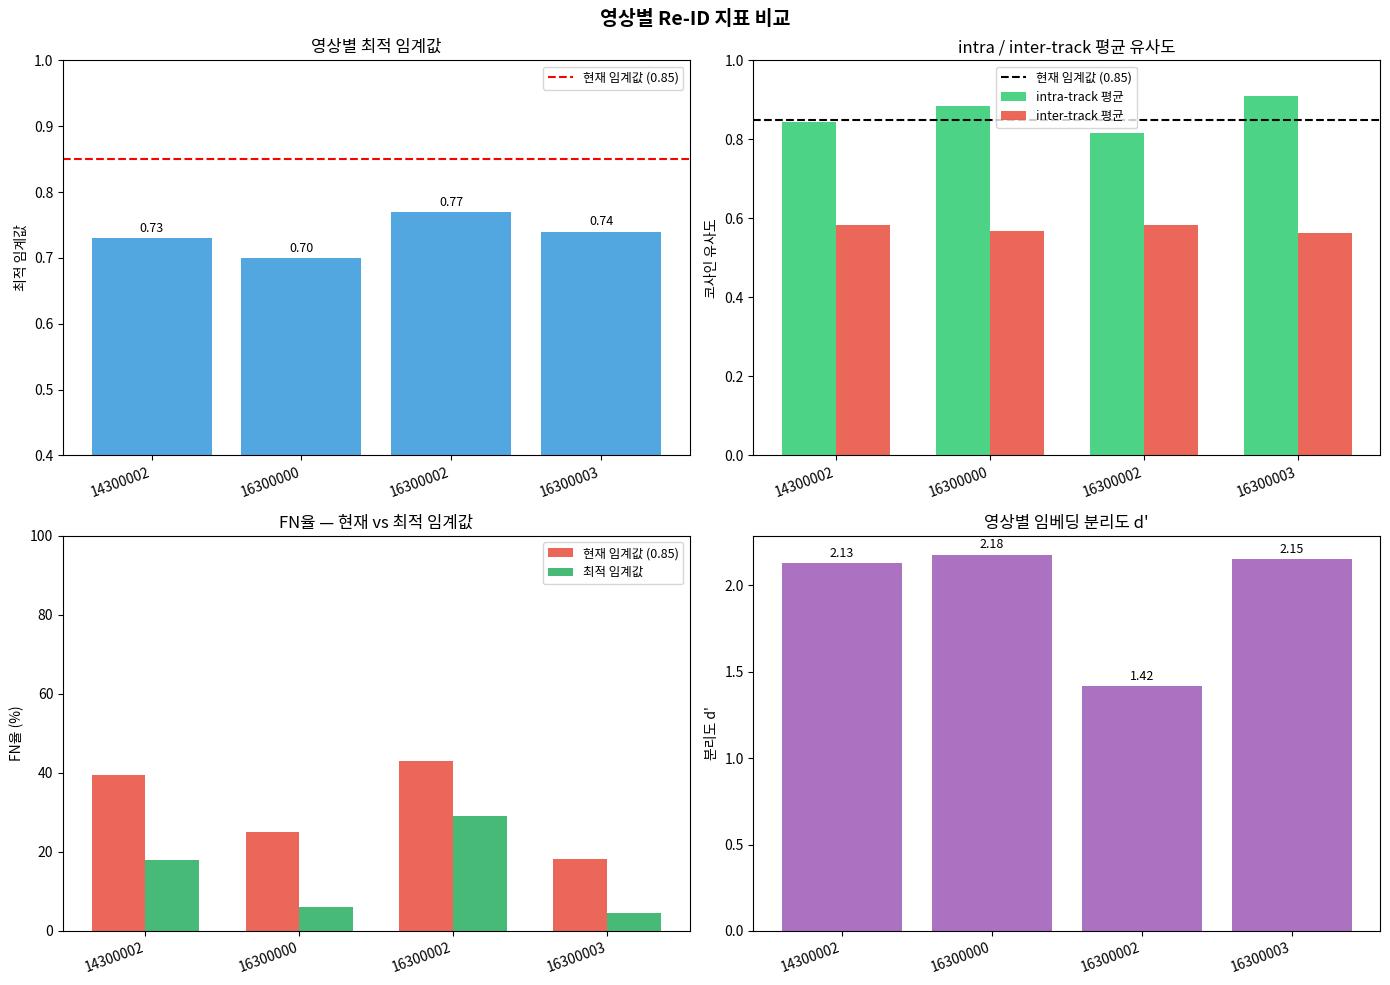

In [4]:
names      = list(all_results.keys())
opt_thrs   = [all_results[n]['opt_threshold']      for n in names]
intra_mean = [all_results[n]['intra_x025'].mean()  for n in names]
inter_mean = [all_results[n]['inter_x025'].mean()  for n in names]
intra_std  = [all_results[n]['intra_x025'].std()   for n in names]

def sep(r):
    intra = r['intra_x025']
    inter = r['inter_x025']
    all_s = np.concatenate([intra, inter])
    return (intra.mean() - inter.mean()) / (all_s.std() + 1e-8)

fn_curr = [(r['intra_x025'] < CURRENT_THRESHOLD).mean() for r in all_results.values()]
fn_opt  = [(r['intra_x025'] < r['opt_threshold']).mean()  for r in all_results.values()]
seps    = [sep(r) for r in all_results.values()]

x  = np.arange(len(names))
w  = 0.35
short_names = [n[:15] for n in names]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('영상별 Re-ID 지표 비교', fontsize=14, fontweight='bold')

# 최적 임계값
ax = axes[0, 0]
bars = ax.bar(x, opt_thrs, color='#3498db', alpha=0.85)
ax.axhline(CURRENT_THRESHOLD, color='red', lw=1.5, ls='--', label=f'현재 임계값 ({CURRENT_THRESHOLD})')
for bar, v in zip(bars, opt_thrs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=20, ha='right')
ax.set_ylabel('최적 임계값'); ax.set_title('영상별 최적 임계값'); ax.legend(fontsize=9)
ax.set_ylim(0.4, 1.0)

# intra/inter 평균 유사도
ax = axes[0, 1]
ax.bar(x - w/2, intra_mean, w, color='#2ecc71', alpha=0.85, label='intra-track 평균')
ax.bar(x + w/2, inter_mean, w, color='#e74c3c', alpha=0.85, label='inter-track 평균')
ax.axhline(CURRENT_THRESHOLD, color='black', lw=1.5, ls='--', label=f'현재 임계값 ({CURRENT_THRESHOLD})')
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=20, ha='right')
ax.set_ylabel('코사인 유사도'); ax.set_title('intra / inter-track 평균 유사도')
ax.legend(fontsize=9); ax.set_ylim(0, 1)

# FN율 비교 (현재 vs 최적)
ax = axes[1, 0]
ax.bar(x - w/2, [v*100 for v in fn_curr], w, color='#e74c3c', alpha=0.85, label=f'현재 임계값 ({CURRENT_THRESHOLD})')
ax.bar(x + w/2, [v*100 for v in fn_opt],  w, color='#27ae60', alpha=0.85, label='최적 임계값')
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=20, ha='right')
ax.set_ylabel('FN율 (%)'); ax.set_title('FN율 — 현재 vs 최적 임계값')
ax.legend(fontsize=9); ax.set_ylim(0, 100)

# 분리도 d'
ax = axes[1, 1]
bars = ax.bar(x, seps, color='#9b59b6', alpha=0.85)
for bar, v in zip(bars, seps):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=20, ha='right')
ax.set_ylabel("분리도 d'"); ax.set_title("영상별 임베딩 분리도 d'")

plt.tight_layout()
plt.show()

## 3. 합산 유사도 분포 분석

합산 intra: 9381쌍  mean=0.883  std=0.109
합산 inter: 1655쌍  mean=0.565  std=0.095


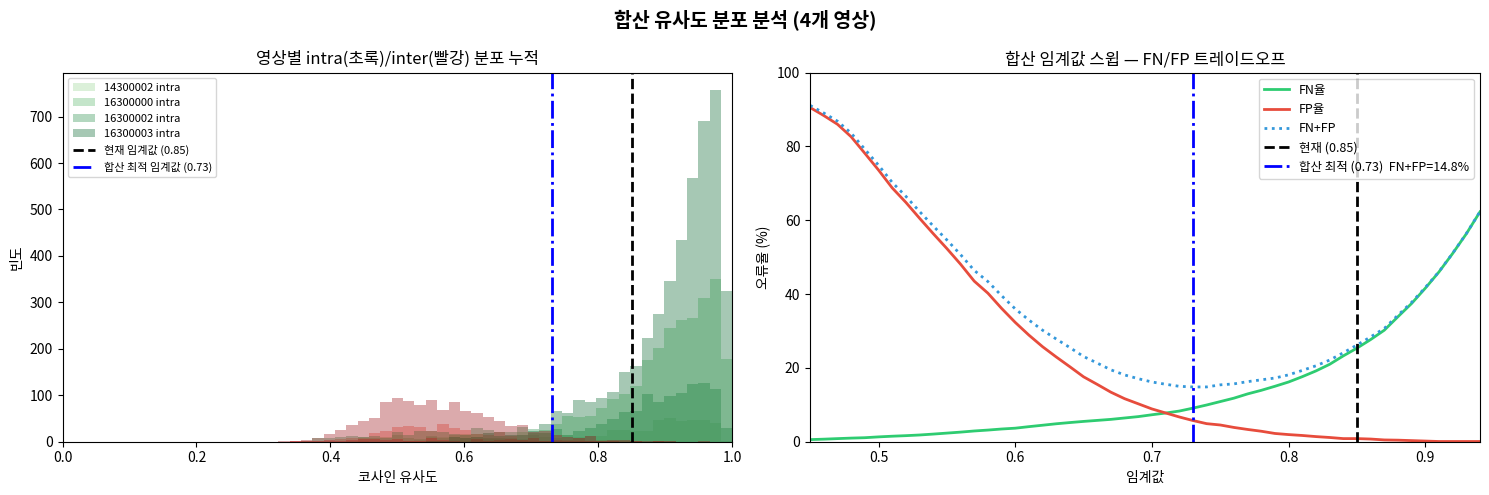


[합산 결과]
  현재  0.85: FN=25.3%
  합산 최적 임계값: 0.73  (FN+FP=14.8%)


In [5]:
# 모든 영상의 intra/inter 분포 합산
all_intra = np.concatenate([r['intra_x025'] for r in all_results.values()])
all_inter = np.concatenate([r['inter_x025'] for r in all_results.values()])

print(f'합산 intra: {len(all_intra)}쌍  mean={all_intra.mean():.3f}  std={all_intra.std():.3f}')
print(f'합산 inter: {len(all_inter)}쌍  mean={all_inter.mean():.3f}  std={all_inter.std():.3f}')

# 합산 기반 최적 임계값
fn_rates = np.array([(all_intra < t).mean() for t in THRESHOLD_RANGE])
fp_rates = np.array([(all_inter >= t).mean() for t in THRESHOLD_RANGE])
total    = fn_rates + fp_rates
opt_idx  = np.argmin(total)
opt_t    = THRESHOLD_RANGE[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'합산 유사도 분포 분석 ({len(all_results)}개 영상)', fontsize=14, fontweight='bold')

# 분포 히스토그램 (영상별 색상 누적)
ax = axes[0]
bins = np.linspace(0, 1, 60)
colors_intra = plt.cm.Greens(np.linspace(0.4, 0.9, len(all_results)))
colors_inter = plt.cm.Reds(np.linspace(0.4, 0.9, len(all_results)))
for (name, r), ci, cr in zip(all_results.items(), colors_intra, colors_inter):
    ax.hist(r['intra_x025'], bins=bins, alpha=0.35, color=ci, label=f'{name[:12]} intra')
    ax.hist(r['inter_x025'], bins=bins, alpha=0.35, color=cr)
ax.axvline(CURRENT_THRESHOLD, color='black', lw=2, ls='--', label=f'현재 임계값 ({CURRENT_THRESHOLD})')
ax.axvline(opt_t, color='blue', lw=2, ls='-.', label=f'합산 최적 임계값 ({opt_t:.2f})')
ax.set_xlabel('코사인 유사도'); ax.set_ylabel('빈도')
ax.set_title('영상별 intra(초록)/inter(빨강) 분포 누적')
ax.legend(fontsize=8); ax.set_xlim(0, 1)

# 합산 임계값 스윕
ax = axes[1]
ax.plot(THRESHOLD_RANGE, fn_rates * 100, '#2ecc71', lw=2, label='FN율')
ax.plot(THRESHOLD_RANGE, fp_rates * 100, '#e74c3c', lw=2, label='FP율')
ax.plot(THRESHOLD_RANGE, total * 100,    '#3498db', lw=2, ls=':', label='FN+FP')
ax.axvline(CURRENT_THRESHOLD, color='black', lw=2, ls='--', label=f'현재 ({CURRENT_THRESHOLD})')
ax.axvline(opt_t, color='blue', lw=2, ls='-.',
           label=f'합산 최적 ({opt_t:.2f})  FN+FP={total[opt_idx]*100:.1f}%')
ax.set_xlabel('임계값'); ax.set_ylabel('오류율 (%)')
ax.set_title('합산 임계값 스윕 — FN/FP 트레이드오프')
ax.legend(fontsize=9); ax.set_ylim(0, 100)
ax.set_xlim(THRESHOLD_RANGE[0], THRESHOLD_RANGE[-1])

plt.tight_layout()
plt.show()

print(f'\n[합산 결과]')
print(f'  현재  {CURRENT_THRESHOLD:.2f}: FN={fn_rates[np.searchsorted(THRESHOLD_RANGE, CURRENT_THRESHOLD)]*100:.1f}%')
print(f'  합산 최적 임계값: {opt_t:.2f}  (FN+FP={total[opt_idx]*100:.1f}%)')

## 4. 최종 권고사항

In [7]:
print('=' * 60)
print('  다중 영상 통합 Re-ID 진단 최종 권고')
print('=' * 60)
print(f'\n  분석 영상 수: {len(all_results)}개')
print(f'  합산 intra: {len(all_intra)}쌍  |  inter: {len(all_inter)}쌍')

all_sep = (all_intra.mean() - all_inter.mean()) / (np.concatenate([all_intra, all_inter]).std() + 1e-8)
print(f"\n  합산 분리도 d' = {all_sep:.2f}")
print(f'  합산 intra 평균 = {all_intra.mean():.3f}  std = {all_intra.std():.3f}')
print(f'  합산 inter 평균 = {all_inter.mean():.3f}  std = {all_inter.std():.3f}')

curr_fn = (all_intra < CURRENT_THRESHOLD).mean()
curr_fp = (all_inter >= CURRENT_THRESHOLD).mean()
opt_fn  = (all_intra < opt_t).mean()
opt_fp  = (all_inter >= opt_t).mean()

print(f'\n  현재 임계값 {CURRENT_THRESHOLD:.2f}: FN={curr_fn*100:.1f}%  FP={curr_fp*100:.1f}%')
print(f'  합산 최적   {opt_t:.2f}: FN={opt_fn*100:.1f}%   FP={opt_fp*100:.1f}%')

print(f'\n  영상별 최적 임계값 범위: {min(opt_thrs):.2f} ~ {max(opt_thrs):.2f}')
print(f"  => 환경 간 편차가 {'크면' if max(opt_thrs)-min(opt_thrs) > 0.1 else '작으면'} 단일 임계값으로 커버 {'어려움' if max(opt_thrs)-min(opt_thrs) > 0.1 else '가능'}")

print(f'\n[권장 적용 사항]')
print(f'  1. .env REID_SIMILARITY_THRESHOLD={opt_t:.2f}  (합산 기준 최적값)')
print(f'  2. 영상별 편차가 크다면 카메라별 임계값 개별 설정 검토')
print('=' * 60)

  다중 영상 통합 Re-ID 진단 최종 권고

  분석 영상 수: 4개
  합산 intra: 9381쌍  |  inter: 1655쌍

  합산 분리도 d' = 2.04
  합산 intra 평균 = 0.883  std = 0.109
  합산 inter 평균 = 0.565  std = 0.095

  현재 임계값 0.85: FN=25.3%  FP=0.8%
  합산 최적   0.73: FN=9.1%   FP=5.7%

  영상별 최적 임계값 범위: 0.70 ~ 0.77
  => 환경 간 편차가 작으면 단일 임계값으로 커버 가능

[권장 적용 사항]
  1. .env REID_SIMILARITY_THRESHOLD=0.73  (합산 기준 최적값)
  2. 영상별 편차가 크다면 카메라별 임계값 개별 설정 검토
